## GSEA-Based Cell Type Annotation of cNMF Gene Expression Programs

**Logic:**
1. For each K, load the usage matrix (cells × GEPs)
2. For each GEP, rank all cells by their usage score
3. Treat cell type annotations as "gene sets" (i.e., sets of cell barcodes)
4. Run GSEA prerank: walk down the ranked cell list and compute enrichment for each cell type
5. Collect NES scores → one CSV per K value (rows = GEPs, columns = cell types)

In [1]:
import os
import glob
import re
import pandas as pd
import numpy as np
import gseapy as gp
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### 1. Configuration

In [2]:
# Folder containing all cNMF result files
CNMF_DIR = "hnc_consensus_outputs_k4-20/local_run"

# cNMF run name prefix (the part before .usages., .gene_spectra_score., etc.)
CNMF_PREFIX = "local_run"  

# Density threshold used in cNMF (appears in filenames as dt_0_01, dt_0_02, etc.)
DENSITY_THRESHOLD = "0_01"  

# Path to cell type metadata file
# Expected: a CSV/TSV with at least two columns:
#   - one column with cell barcodes (matching the index of the usage matrix)
#   - one column with cell type annotations
METADATA_PATH = "hnc_data/hnc_myeloid_globalcluster4.csv"

# Column names in the metadata file
BARCODE_COL = None    # Set to column name if barcodes are NOT the index; None = use index
CELLTYPE_COL = "global.cluster4"  # Column containing cell type annotations

# Separator for metadata file
METADATA_SEP = "," 

# Output directory for NES CSVs
OUTPUT_DIR = "hnc_1000hvg-percelltype_clanp_results/k4-20_gsea_celltype_results"

# K range
K_MIN = 4
K_MAX = 20

# GSEA parameters
GSEA_PERMUTATIONS = 1000  # Number of permutations for significance testing
GSEA_SEED = 42
GSEA_THREADS = 4  # Number of parallel threads
MIN_SET_SIZE = 15  # Minimum number of cells in a cell type to include

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuration loaded.")

Configuration loaded.


#### 2. Load Cell Type Annotations & Build Cell Type Sets

In [3]:
# Load metadata
meta = pd.read_csv(METADATA_PATH, sep=METADATA_SEP, index_col=0 if BARCODE_COL is None else None)

if BARCODE_COL is not None:
    meta = meta.set_index(BARCODE_COL)

# Ensure index is string
meta.index = meta.index.astype(str)

print(f"Loaded metadata for {len(meta)} cells")
print(f"\nCell type distribution:")
print(meta[CELLTYPE_COL].value_counts())

Loaded metadata for 26444 cells

Cell type distribution:
global.cluster4
Mono_CD14          7518
Mono_CD16          2503
Mac_IL1Bint        1842
Mono_CD14_IL1B     1801
Mono_CD14_THBS1    1783
Mono_Int           1684
cDC2_CD33          1319
Mac_CXCL9          1225
DC_pDC             1218
Mono_CD14_ID1      1154
Mono_TIL            988
cDC2_CD1C           966
Mac_IL1B            774
Mac_SPP1            573
mregDC_LAMP3        482
Mast                313
cDC1_CLEC9A         301
Name: count, dtype: int64


In [4]:
# Build cell type "gene sets" dictionary: {cell_type: [list of barcodes]}
celltype_sets = {}
for ct, group in meta.groupby(CELLTYPE_COL):
    barcodes = group.index.tolist()
    if len(barcodes) >= MIN_SET_SIZE:
        celltype_sets[ct] = barcodes
    else:
        print(f"  Skipping '{ct}' — only {len(barcodes)} cells (min={MIN_SET_SIZE})")

print(f"\n{len(celltype_sets)} cell types included in GSEA:")
for ct, barcodes in sorted(celltype_sets.items(), key=lambda x: -len(x[1])):
    print(f"  {ct}: {len(barcodes)} cells")


17 cell types included in GSEA:
  Mono_CD14: 7518 cells
  Mono_CD16: 2503 cells
  Mac_IL1Bint: 1842 cells
  Mono_CD14_IL1B: 1801 cells
  Mono_CD14_THBS1: 1783 cells
  Mono_Int: 1684 cells
  cDC2_CD33: 1319 cells
  Mac_CXCL9: 1225 cells
  DC_pDC: 1218 cells
  Mono_CD14_ID1: 1154 cells
  Mono_TIL: 988 cells
  cDC2_CD1C: 966 cells
  Mac_IL1B: 774 cells
  Mac_SPP1: 573 cells
  mregDC_LAMP3: 482 cells
  Mast: 313 cells
  cDC1_CLEC9A: 301 cells


#### 3. Discover Available K Values

In [5]:
# Find all usage matrix files and extract K values
usage_pattern = os.path.join(CNMF_DIR, f"{CNMF_PREFIX}.usages.k_*.dt_{DENSITY_THRESHOLD}.consensus.txt")
usage_files = sorted(glob.glob(usage_pattern))

# Extract K values from filenames
k_values = []
for f in usage_files:
    match = re.search(r'k_(\d+)', os.path.basename(f))
    if match:
        k = int(match.group(1))
        if K_MIN <= k <= K_MAX:
            k_values.append(k)

k_values = sorted(k_values)
print(f"Found {len(k_values)} K values: {k_values}")

Found 17 K values: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


#### 4. Run GSEA for Each K and Each GEP

For each GEP within a given K:
1. Extract usage scores for that GEP (one value per cell)
2. Use these as the "preranked" metric
3. Run `gseapy.prerank` with cell type sets
4. Collect NES for each cell type

In [6]:
def run_gsea_for_k(k, cnmf_dir, prefix, dt, celltype_sets, meta):
    """
    For a given K, load the usage matrix, run GSEA prerank for each GEP,
    and return a DataFrame of NES scores (GEPs x cell types).
    """
    # Load usage matrix
    usage_path = os.path.join(cnmf_dir, f"{prefix}.usages.k_{k}.dt_{dt}.consensus.txt")
    usage = pd.read_csv(usage_path, sep='\t', index_col=0)
    usage.index = usage.index.astype(str)
    
    print(f"\n{'='*60}")
    print(f"K = {k} | {usage.shape[1]} GEPs | {usage.shape[0]} cells")
    print(f"{'='*60}")
    
    # Find overlapping cells between usage matrix and metadata
    common_cells = usage.index.intersection(meta.index)
    if len(common_cells) < len(usage):
        print(f"  Warning: {len(usage) - len(common_cells)} cells in usage matrix not found in metadata")
    usage = usage.loc[common_cells]
    
    # Filter cell type sets to only include cells present in this usage matrix
    celltype_sets_filtered = {}
    for ct, barcodes in celltype_sets.items():
        filtered = [b for b in barcodes if b in common_cells]
        if len(filtered) >= MIN_SET_SIZE:
            celltype_sets_filtered[ct] = filtered
    
    # Collect NES results
    nes_results = {}
    pval_results = {}
    fdr_results = {}
    
    for gep_col in usage.columns:
        gep_name = gep_col if isinstance(gep_col, str) else f"GEP_{gep_col}"
        
        # Rank cells by usage of this GEP
        # gseapy.prerank expects a Series or DataFrame with numeric ranking metric
        ranked_cells = usage[gep_col].sort_values(ascending=False)
        
        # Run GSEA prerank
        try:
            res = gp.prerank(
                rnk=ranked_cells,
                gene_sets=celltype_sets_filtered,
                permutation_num=GSEA_PERMUTATIONS,
                outdir=None,  # Don't write intermediate files
                seed=GSEA_SEED,
                threads=GSEA_THREADS,
                min_size=MIN_SET_SIZE,
                max_size=len(common_cells),  # No upper limit
                verbose=False,
            )
            
            # Extract NES, p-value, and FDR for each cell type
            gsea_df = res.res2d
            nes_results[gep_name] = gsea_df.set_index('Term')['NES'].to_dict()
            pval_results[gep_name] = gsea_df.set_index('Term')['NOM p-val'].to_dict()
            fdr_results[gep_name] = gsea_df.set_index('Term')['FDR q-val'].to_dict()
            
            # Print top hit
            top_ct = gsea_df.loc[gsea_df['NES'].astype(float).idxmax(), 'Term']
            top_nes = gsea_df['NES'].astype(float).max()
            print(f"  {gep_name} → top cell type: {top_ct} (NES={top_nes:.2f})")
            
        except Exception as e:
            print(f"  {gep_name} → GSEA failed: {e}")
            nes_results[gep_name] = {}
            pval_results[gep_name] = {}
            fdr_results[gep_name] = {}
    
    # Build DataFrames
    nes_df = pd.DataFrame(nes_results).T.astype(float)
    pval_df = pd.DataFrame(pval_results).T.astype(float)
    fdr_df = pd.DataFrame(fdr_results).T.astype(float)
    
    # Sort columns (cell types) alphabetically
    nes_df = nes_df.reindex(sorted(nes_df.columns), axis=1)
    pval_df = pval_df.reindex(sorted(pval_df.columns), axis=1)
    fdr_df = fdr_df.reindex(sorted(fdr_df.columns), axis=1)
    
    nes_df.index.name = 'GEP'
    pval_df.index.name = 'GEP'
    fdr_df.index.name = 'GEP'
    
    return nes_df, pval_df, fdr_df

In [7]:
# Run GSEA for all K values
all_nes = {}  # k -> nes_df
all_fdr = {}  # k -> fdr_df   (retained for program-class classification in Section 7)

for k in k_values:
    nes_df, pval_df, fdr_df = run_gsea_for_k(
        k=k,
        cnmf_dir=CNMF_DIR,
        prefix=CNMF_PREFIX,
        dt=DENSITY_THRESHOLD,
        celltype_sets=celltype_sets,
        meta=meta,
    )
    
    all_nes[k] = nes_df
    all_fdr[k] = fdr_df
    
    # Save NES scores (primary output)
    nes_path = os.path.join(OUTPUT_DIR, f"NES_k{k}.csv")
    nes_df.to_csv(nes_path)
    
    # Save p-values and FDR 
    pval_df.to_csv(os.path.join(OUTPUT_DIR, f"pval_k{k}.csv"))
    fdr_df.to_csv(os.path.join(OUTPUT_DIR, f"fdr_k{k}.csv"))
    
    print(f"  Saved → {nes_path}")

print(f"\nDone! All results saved to '{OUTPUT_DIR}/'.")

2026-08-26 14:41:55,045 [WARNING] Duplicated values found in preranked stats: 6.29% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



K = 4 | 4 GEPs | 26444 cells


2026-08-26 14:41:56,162 [WARNING] Duplicated values found in preranked stats: 41.77% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  1 → top cell type: Mono_CD16 (NES=2.41)


2026-08-26 14:41:57,192 [WARNING] Duplicated values found in preranked stats: 55.59% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


...

  17 → top cell type: Mac_SPP1 (NES=1.12)


2026-08-26 14:45:15,590 [WARNING] Duplicated values found in preranked stats: 74.32% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  18 → top cell type: cDC2_CD1C (NES=1.11)


2026-08-26 14:45:16,601 [WARNING] Duplicated values found in preranked stats: 85.17% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  19 → top cell type: cDC2_CD1C (NES=1.11)
  20 → top cell type: Mac_SPP1 (NES=1.08)
  Saved → hnc_1000hvg-percelltype_clanp_results/k4-20_gsea_celltype_results/NES_k20.csv

Done! All results saved to 'hnc_1000hvg-percelltype_clanp_results/k4-20_gsea_celltype_results/'.


#### 5. Quick Summary: Top Cell Type per GEP

In [8]:
# For each K, show the dominant cell type per GEP
summary_rows = []

for k in sorted(all_nes.keys()):
    nes_df = all_nes[k]
    for gep in nes_df.index:
        top_ct = nes_df.loc[gep].idxmax()
        top_nes = nes_df.loc[gep].max()
        summary_rows.append({
            'K': k,
            'GEP': gep,
            'Top_CellType': top_ct,
            'NES': round(top_nes, 3)
        })

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUTPUT_DIR, "summary_top_celltype_per_gep.csv")
summary_df.to_csv(summary_path, index=False)

print("Top cell type assignment per GEP (all K values):")
print("="*60)
for k in sorted(all_nes.keys()):
    subset = summary_df[summary_df['K'] == k]
    print(f"\nK = {k}:")
    for _, row in subset.iterrows():
        print(f"  {row['GEP']:>15} → {row['Top_CellType']:<25} (NES={row['NES']:.2f})")

print(f"\nSummary saved to: {summary_path}")

Top cell type assignment per GEP (all K values):

K = 4:
                1 → Mono_CD16                 (NES=2.41)
                2 → Mac_CXCL9                 (NES=1.28)
                3 → mregDC_LAMP3              (NES=1.17)
                4 → DC_pDC                    (NES=1.31)

K = 5:
                1 → Mono_CD16                 (NES=2.35)
                2 → Mac_CXCL9                 (NES=1.28)
                3 → mregDC_LAMP3              (NES=1.27)
                4 → DC_pDC                    (NES=1.29)
                5 → cDC1_CLEC9A               (NES=1.18)

K = 6:
                1 → Mono_CD16                 (NES=2.31)
                2 → Mac_CXCL9                 (NES=1.26)
                3 → mregDC_LAMP3              (NES=1.25)
                4 → Mac_IL1B                  (NES=1.27)
                5 → DC_pDC                    (NES=1.30)
                6 → cDC1_CLEC9A               (NES=1.19)

K = 7:
                1 → Mono_CD16                 (NES=2.32)
       

#### 6. Heatmap Visualization 

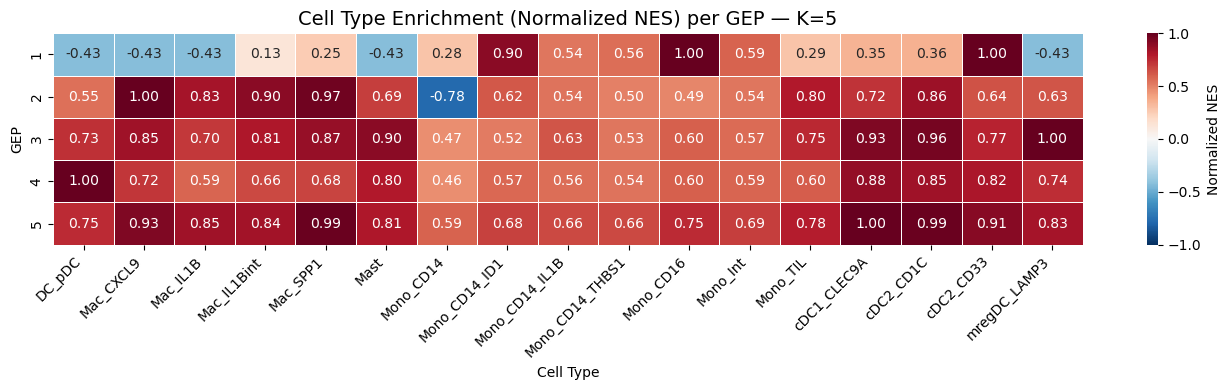

In [9]:
K_TO_PLOT = 5

if K_TO_PLOT in all_nes:
    nes_df = all_nes[K_TO_PLOT].astype(float)

    # Row-wise max-abs normalization: each GEP scaled to [-1, 1] by its own peak
    nes_norm = nes_df.div(nes_df.abs().max(axis=1), axis=0).fillna(0)

    fig, ax = plt.subplots(figsize=(max(12, len(nes_norm.columns) * 0.8), max(4, len(nes_norm) * 0.5)))
    sns.heatmap(
        nes_norm,
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        annot=True,
        fmt='.2f',
        linewidths=0.5,
        ax=ax,
        cbar_kws={'label': 'Normalized NES'}
    )
    ax.set_title(f'Cell Type Enrichment (Normalized NES) per GEP — K={K_TO_PLOT}', fontsize=14)
    ax.set_xlabel('Cell Type')
    ax.set_ylabel('GEP')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"K={K_TO_PLOT} not found. Available: {sorted(all_nes.keys())}")

#### 7. Program-Class Classification (NB1 → NB4.5 hand-off)

Classify every `(K, GEP)` into one of three classes from the GSEA evidence above, for use by NB4.5.

| Program class | Meaning | Use in NB4.5 |
|---|---|---|
| `identity_supported` | one identity set clearly dominates | Include as an identity GEP |
| `identity_ambiguous` | two or more identity sets are significant and close | Include as identity evidence, flag uncertainty |
| `non_identity_unresolved` | no cell type enriches significantly | Exclude from identity-only metrics |

**Classification rule:**
```
significant_identity = (NES > 0) AND (FDR <= alpha) AND (NES >= effect_size_floor)
```
- 0 significant sets → `non_identity_unresolved`
- 1 significant set, or top set clearly ahead of the runner-up → `identity_supported`
- ≥2 significant sets close in NES → `identity_ambiguous`

**Deliverable:** `gep_program_class.tsv`. **Silent-failure check 1** — every `(K, GEP)` in the cNMF usage files must appear exactly once, with a valid class.

In [10]:
# Program-class configuration

# Significance gate: does any cell type enrich this GEP?
# FDR saturates at 0 for positive sets here, so NES_EFFECT_FLOOR is the real filter.
ALPHA_FDR         = 0.10   # FDR q-value cutoff for a "significant" identity set
NES_EFFECT_FLOOR  = 1.3    # minimum NES to count as a real effect (not just >0)

# Supported-vs-ambiguous gate: ratio of runner-up to top significant NES.
#   ratio -> 0 : top set dominates          -> identity_supported
#   ratio -> 1 : top and runner-up are tied -> identity_ambiguous
RUNNER_UP_RATIO_MAX = 0.80  # ratio <= this -> supported; else ambiguous

# nes_gap is recorded in the output for audit only; it does not decide the class
PROGRAM_CLASS_PATH = os.path.join(OUTPUT_DIR, "gep_program_class.tsv")
VALID_CLASSES = {'identity_supported','identity_ambiguous','non_identity_unresolved'}
print("Program-class config loaded. Output ->", PROGRAM_CLASS_PATH)

Program-class config loaded. Output -> hnc_1000hvg-percelltype_clanp_results/k4-20_gsea_celltype_results/gep_program_class.tsv


NES  quantiles:
0.50    0.933
0.75    1.057
0.90    1.178
0.95    1.280
0.99    1.688

Fraction of NES values > 0        : 97.32%
Fraction with NES >= 1.3          : 4.33%
Fraction with FDR <= 0.1          : 29.41%


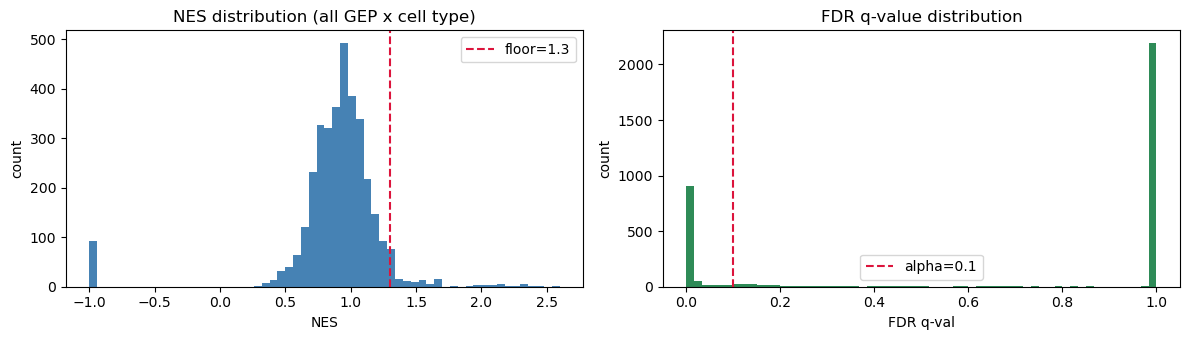

In [11]:
# 7.2 Inspect NES / FDR distributions before fixing thresholds

# Pool every (GEP x cell-type) NES/FDR value across all K and preview the
# class split under the current thresholds in 7.1.
_nes_all = pd.concat([df.stack() for df in all_nes.values()], ignore_index=True)
_fdr_all = pd.concat([df.stack() for df in all_fdr.values()], ignore_index=True)
_nes_all = pd.to_numeric(_nes_all, errors='coerce').dropna()
_fdr_all = pd.to_numeric(_fdr_all, errors='coerce').dropna()

print("NES  quantiles:")
print(_nes_all.quantile([.5,.75,.9,.95,.99]).round(3).to_string())
print(f"\nFraction of NES values > 0        : {(_nes_all > 0).mean():.2%}")
print(f"Fraction with NES >= {NES_EFFECT_FLOOR:<4}         : {(_nes_all >= NES_EFFECT_FLOOR).mean():.2%}")
print(f"Fraction with FDR <= {ALPHA_FDR:<4}         : {(_fdr_all <= ALPHA_FDR).mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(_nes_all, bins=60, color='steelblue')
axes[0].axvline(NES_EFFECT_FLOOR, color='crimson', ls='--', label=f'floor={NES_EFFECT_FLOOR}')
axes[0].set(title='NES distribution (all GEP x cell type)', xlabel='NES', ylabel='count'); axes[0].legend()
axes[1].hist(_fdr_all, bins=60, color='seagreen')
axes[1].axvline(ALPHA_FDR, color='crimson', ls='--', label=f'alpha={ALPHA_FDR}')
axes[1].set(title='FDR q-value distribution', xlabel='FDR q-val', ylabel='count'); axes[1].legend()
plt.tight_layout(); plt.show()

FDR saturation: 20% of all q-values are exactly 0.0 -> ALPHA_FDR is doing little filtering; NES_EFFECT_FLOOR is the real gate.

GEPs with >=1 significant identity set: 64/204
runner_up_ratio quantiles (GEPs with >=1 sig):
0.10    0.000
0.25    0.000
0.50    0.787
0.75    0.857
0.90    0.946 

Median runner_up_ratio by K bucket (lower = cleaner single identity):
k
K 3-8      0.944
K 9-20     0.389
K 21-35      NaN 

Class split vs RUNNER_UP_RATIO_MAX (tau):
  tau  supported  ambiguous  unresolved
  0.7         29         35         140
 0.75         29         35         140
  0.8         41         23         140
 0.85         48         16         140
  0.9         52         12         140


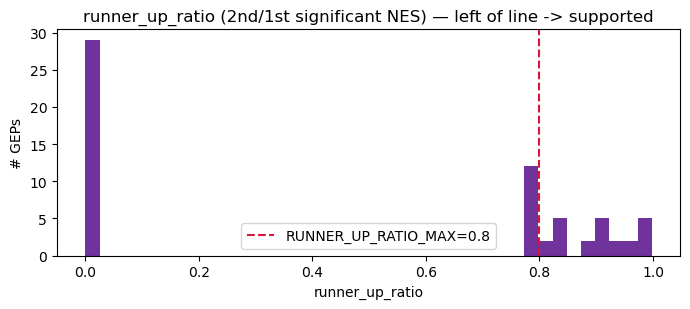

In [12]:
# 7.3 Dominance diagnostic

# For each GEP, find its significant identity sets and compute runner_up_ratio
# (2nd-highest significant NES / top significant NES). 
# Use the distribution below to pick RUNNER_UP_RATIO_MAX.
def _sig_and_ratio(nes_row, fdr_row, alpha, floor):
    nes = pd.to_numeric(nes_row, errors='coerce')
    vals = [(ct, float(nes[ct]), float(fdr_row.get(ct, np.nan)))
            for ct in nes.index if pd.notna(nes[ct])]
    sig = [(c, n, f) for c, n, f in vals
           if (n > 0) and pd.notna(f) and (f <= alpha) and (n >= floor)]
    sig.sort(key=lambda x: -x[1])
    if not sig:
        return 0, np.nan
    top = sig[0][1]; runner = sig[1][1] if len(sig) >= 2 else 0.0
    return len(sig), (runner / top if top > 0 else 1.0)

diag = []
for k in sorted(all_nes.keys()):
    for gep in all_nes[k].index:
        fdr_row = all_fdr[k].loc[gep] if gep in all_fdr[k].index else pd.Series(dtype=float)
        nsig, ratio = _sig_and_ratio(all_nes[k].loc[gep], fdr_row, ALPHA_FDR, NES_EFFECT_FLOOR)
        diag.append({'k': k, 'gep': str(gep), 'n_sig': nsig, 'runner_up_ratio': ratio})
diag = pd.DataFrame(diag)
has_sig = diag[diag['n_sig'] >= 1]

# FDR saturation check
all_fdr_pos = pd.concat([df.stack() for df in all_fdr.values()], ignore_index=True)
all_fdr_pos = pd.to_numeric(all_fdr_pos, errors='coerce').dropna()
print(f"FDR saturation: {(all_fdr_pos == 0).mean():.0%} of all q-values are exactly 0.0 "
      f"-> ALPHA_FDR is doing little filtering; NES_EFFECT_FLOOR is the real gate.\n")

print(f"GEPs with >=1 significant identity set: {len(has_sig)}/{len(diag)}")
print("runner_up_ratio quantiles (GEPs with >=1 sig):")
print(has_sig['runner_up_ratio'].quantile([.1,.25,.5,.75,.9]).round(3).to_string(), "\n")

# Does resolution improve with K? (low ratio = cleaner single identity)
buckets = pd.cut(has_sig['k'], [2,8,20,35], labels=['K 3-8','K 9-20','K 21-35'])
print("Median runner_up_ratio by K bucket (lower = cleaner single identity):")
print(has_sig.groupby(buckets)['runner_up_ratio'].median().round(3).to_string(), "\n")

# tau sweep: resulting class split
print("Class split vs RUNNER_UP_RATIO_MAX (tau):")
print(f"{'tau':>5} {'supported':>10} {'ambiguous':>10} {'unresolved':>11}")
n_unres = int((diag['n_sig'] == 0).sum())
for tau in [0.70, 0.75, 0.80, 0.85, 0.90]:
    sup = int((has_sig['runner_up_ratio'] <= tau).sum())
    amb = len(has_sig) - sup
    print(f"{tau:>5} {sup:>10} {amb:>10} {n_unres:>11}")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(has_sig['runner_up_ratio'].dropna(), bins=40, color='indigo', alpha=.8)
ax.axvline(RUNNER_UP_RATIO_MAX, color='crimson', ls='--',
           label=f'RUNNER_UP_RATIO_MAX={RUNNER_UP_RATIO_MAX}')
ax.set(title='runner_up_ratio (2nd/1st significant NES) — left of line -> supported',
       xlabel='runner_up_ratio', ylabel='# GEPs'); ax.legend()
plt.tight_layout(); plt.show()

In [13]:
# 7.4 Classifier

# Two gates:
#   (1) significance (NES>=floor, FDR<=alpha, NES>0) -> identity vs non_identity_unresolved
#   (2) runner_up_ratio = 2nd/1st significant NES    -> supported vs ambiguous
# nes_gap is retained for audit but does not decide the class.
def classify_gep_row(gep, nes_row, fdr_row, alpha, effect_floor, runner_up_ratio_max):
    r = {'gep': str(gep), 'program_class': None,
         'top_identity_label': None, 'second_identity_label': None,
         'top_identity_nes': np.nan, 'second_identity_nes': np.nan,
         'top_identity_fdr': np.nan, 'second_identity_fdr': np.nan,
         'nes_gap': np.nan, 'runner_up_ratio': np.nan,
         'n_significant_identity_sets': 0,
         'significant_identity_sets': '', 'classification_reason': ''}

    valid = pd.to_numeric(nes_row, errors='coerce').dropna()
    if valid.empty:
        r['program_class'] = 'non_identity_unresolved'
        r['classification_reason'] = 'no GSEA scores (all NES NaN) — likely GSEA failure for this GEP'
        return r

    ordered = valid.sort_values(ascending=False)
    r['top_identity_label'] = ordered.index[0]
    r['top_identity_nes']   = float(ordered.iloc[0])
    r['top_identity_fdr']   = float(pd.to_numeric(pd.Series([fdr_row.get(ordered.index[0], np.nan)]))[0])
    if len(ordered) >= 2:
        r['second_identity_label'] = ordered.index[1]
        r['second_identity_nes']   = float(ordered.iloc[1])
        r['second_identity_fdr']   = float(pd.to_numeric(pd.Series([fdr_row.get(ordered.index[1], np.nan)]))[0])
        r['nes_gap'] = r['top_identity_nes'] - r['second_identity_nes']

    # significant identity sets, sorted by NES desc
    sig = []
    for ct in ordered.index:
        nes = float(valid[ct]); fdr = fdr_row.get(ct, np.nan)
        fdr = float(fdr) if pd.notna(fdr) else np.nan
        if (nes > 0) and pd.notna(fdr) and (fdr <= alpha) and (nes >= effect_floor):
            sig.append((ct, nes, fdr))
    r['n_significant_identity_sets'] = len(sig)
    r['significant_identity_sets'] = '; '.join(f'{c}:NES={n:.3f},q={f:.3g}' for c, n, f in sig)

    n_sig = len(sig)
    if n_sig == 0:
        r['program_class'] = 'non_identity_unresolved'
        r['classification_reason'] = (f'0 significant identity sets '
                                      f'(alpha={alpha}, NES floor={effect_floor})')
        return r

    top_nes = sig[0][1]
    runner_nes = sig[1][1] if n_sig >= 2 else 0.0
    ratio = runner_nes / top_nes if top_nes > 0 else 1.0
    r['runner_up_ratio'] = ratio

    if ratio <= runner_up_ratio_max:
        r['program_class'] = 'identity_supported'
        lead = sig[0][0]
        if n_sig == 1:
            r['classification_reason'] = f'single significant identity ({lead}); no competitor set'
        else:
            r['classification_reason'] = (f'{lead} dominates {n_sig} significant sets '
                                          f'(runner_up_ratio={ratio:.3f} <= {runner_up_ratio_max})')
    else:
        r['program_class'] = 'identity_ambiguous'
        r['classification_reason'] = (f'{n_sig} significant sets, top two near-tied '
                                      f'(runner_up_ratio={ratio:.3f} > {runner_up_ratio_max})')
    return r

print("Classifier defined.")

Classifier defined.


In [14]:
# 7.5 Build the program-class table across all K

SCHEMA_COLS = ['k','gep','program_class',
               'top_identity_label','second_identity_label',
               'top_identity_nes','second_identity_nes',
               'top_identity_fdr','second_identity_fdr',
               'nes_gap','runner_up_ratio','n_significant_identity_sets',
               'significant_identity_sets','classification_reason']

rows = []
for k in sorted(all_nes.keys()):
    nes_df, fdr_df = all_nes[k], all_fdr[k]
    for gep in nes_df.index:
        fdr_row = fdr_df.loc[gep] if gep in fdr_df.index else pd.Series(dtype=float)
        r = classify_gep_row(
            gep, nes_df.loc[gep], fdr_row,
            alpha=ALPHA_FDR, effect_floor=NES_EFFECT_FLOOR,
            runner_up_ratio_max=RUNNER_UP_RATIO_MAX)
        r['k'] = k
        rows.append(r)

gep_program_class = pd.DataFrame(rows)[SCHEMA_COLS].sort_values(['k','gep']).reset_index(drop=True)
print(f"Classified {len(gep_program_class)} (K, GEP) programs across K = {sorted(all_nes.keys())}")
gep_program_class.head(12)

Classified 204 (K, GEP) programs across K = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


,k,gep,program_class,top_identity_label,second_identity_label,top_identity_nes,second_identity_nes,top_identity_fdr,second_identity_fdr,nes_gap,runner_up_ratio,n_significant_identity_sets,significant_identity_sets,classification_reason
0,4,1,identity_ambiguous,Mono_CD16,cDC2_CD33,2.414204,2.408289,0.0,0.0,0.005915,0.997550,5,"Mono_CD16:NES=2.414,q=0; cDC2_CD33:NES=2.408,q...","5 significant sets, top two near-tied (runner_..."
1,4,2,non_identity_unresolved,Mac_CXCL9,Mac_SPP1,1.284352,1.256760,0.0,0.0,0.027592,NaN,0,,"0 significant identity sets (alpha=0.1, NES fl..."
2,4,3,non_identity_unresolved,mregDC_LAMP3,cDC2_CD1C,1.173534,1.164091,0.0,0.0,0.009443,NaN,0,,"0 significant identity sets (alpha=0.1, NES fl..."
3,4,4,identity_supported,DC_pDC,cDC1_CLEC9A,1.312133,1.148341,0.0,0.0,0.163792,0.000000,1,"DC_pDC:NES=1.312,q=0",single significant identity (DC_pDC); no compe...
4,5,1,identity_ambiguous,Mono_CD16,cDC2_CD33,2.345945,2.340415,0.0,0.0,0.005530,0.997643,5,"Mono_CD16:NES=2.346,q=0; cDC2_CD33:NES=2.340,q...","5 significant sets, top two near-tied (runner_..."
5,5,2,non_identity_unresolved,Mac_CXCL9,Mac_SPP1,1.280192,1.242263,0.0,0.0,0.037929,NaN,0,,"0 significant identity sets (alpha=0.1, NES fl..."
6,5,3,non_identity_unresolved,mregDC_LAMP3,cDC2_CD1C,1.268242,1.213714,0.0,0.0,0.054528,NaN,0,,"0 significant identity sets (alpha=0.1, NES fl..."
7,5,4,non_identity_unresolved,DC_pDC,cDC1_CLEC9A,1.295438,1.138424,0.0,0.0,0.157014,NaN,0,,"0 significant identity sets (alpha=0.1, NES fl..."
8,5,5,non_identity_unresolved,cDC1_CLEC9A,Mac_SPP1,1.182335,1.171757,0.0,0.0,0.010579,NaN,0,,"0 significant identity sets (alpha=0.1, NES fl..."
9,6,1,identity_ambiguous,Mono_CD16,cDC2_CD33,2.306810,2.246684,0.0,0.0,0.060126,0.973935,5,"Mono_CD16:NES=2.307,q=0; cDC2_CD33:NES=2.247,q...","5 significant sets, top two near-tied (runner_..."


In [15]:
# 7.6 Silent-failure check 1 — coverage / uniqueness / valid classes

def usage_gep_keys():
    """Authoritative (k, gep) universe read directly from the cNMF usage files."""
    keys = set()
    for k in k_values:
        path = os.path.join(CNMF_DIR, f"{CNMF_PREFIX}.usages.k_{k}.dt_{DENSITY_THRESHOLD}.consensus.txt")
        cols = pd.read_csv(path, sep='\t', index_col=0, nrows=0).columns
        keys |= {(k, str(c)) for c in cols}
    return keys

expected = usage_gep_keys()
got = set(zip(gep_program_class['k'], gep_program_class['gep'].astype(str)))

dups = gep_program_class.duplicated(['k','gep']).sum()
missing = expected - got
extra   = got - expected
bad_cls = set(gep_program_class['program_class']) - VALID_CLASSES

problems = []
if dups:      problems.append(f"{dups} duplicate (K,GEP) key(s)")
if missing:   problems.append(f"{len(missing)} (K,GEP) in usage files but MISSING from table: {sorted(missing)[:10]}")
if extra:     problems.append(f"{len(extra)} (K,GEP) in table but NOT in usage files: {sorted(extra)[:10]}")
if bad_cls:   problems.append(f"invalid program_class value(s): {bad_cls}")

if problems:
    raise ValueError("Silent-failure check 1 FAILED:\n  - " + "\n  - ".join(problems))
print(f"✓ Silent-failure check 1 passed: {len(got)} (K,GEP) keys, "
      f"unique, 100% coverage vs usage files, all classes valid.")

✓ Silent-failure check 1 passed: 204 (K,GEP) keys, unique, 100% coverage vs usage files, all classes valid.


In [16]:
# 7.7 Write gep_program_class.tsv and summarize the class distribution

gep_program_class.to_csv(PROGRAM_CLASS_PATH, sep='\t', index=False)
print(f"Wrote {PROGRAM_CLASS_PATH}  ({len(gep_program_class)} rows)\n")

print("Program-class distribution (overall):")
print(gep_program_class['program_class'].value_counts().to_string())

print("\nPer-K class counts:")
print(pd.crosstab(gep_program_class['k'], gep_program_class['program_class']).to_string())

print("\nHand-off: NB4.5 reads gep_program_class.tsv; identity_supported/ambiguous "
      "feed identity-diversity metrics, non_identity_unresolved is excluded.")

Wrote hnc_1000hvg-percelltype_clanp_results/k4-20_gsea_celltype_results/gep_program_class.tsv  (204 rows)

Program-class distribution (overall):
program_class
non_identity_unresolved    140
identity_supported          41
identity_ambiguous          23

Per-K class counts:
program_class  identity_ambiguous  identity_supported  non_identity_unresolved
k                                                                             
4                               1                   1                        2
5                               1                   0                        4
6                               1                   0                        5
7                               2                   0                        5
8                               2                   0                        6
9                               1                   1                        7
10                              1                   1                        8
11              

#### 8. Program-class composition by K

How the three 7 classes (`identity_supported`, `identity_ambiguous`, `non_identity_unresolved`) split out at each K, stacked so the bar length itself tracks the growing number of GEPs (`n_total_GEPs == K`).

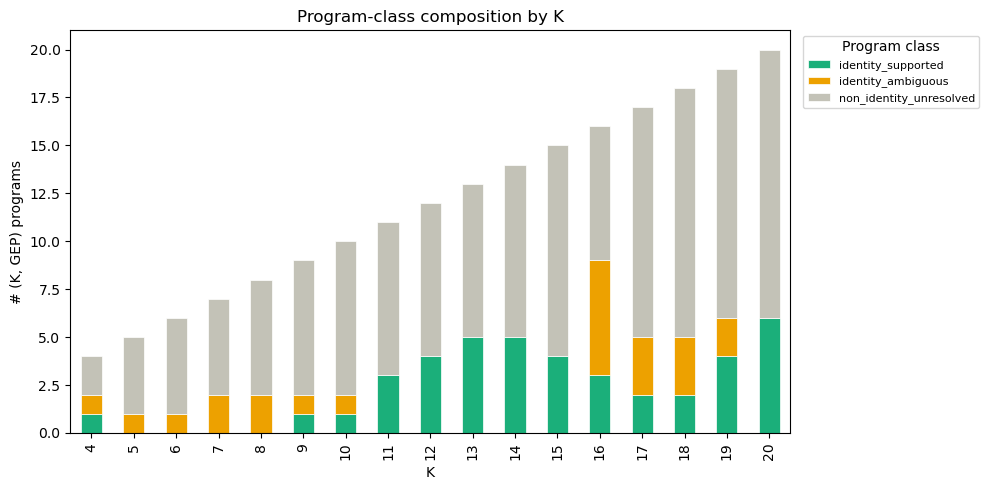

In [17]:
class_by_k = pd.crosstab(gep_program_class['k'], gep_program_class['program_class'])
class_by_k = class_by_k.reindex(
    columns=['identity_supported', 'identity_ambiguous', 'non_identity_unresolved'], fill_value=0
)

fig, ax = plt.subplots(figsize=(10, 5))
class_by_k.plot(kind='bar', stacked=True, ax=ax,
                 color=['#1baf7a', '#eda100', '#c3c2b7'], edgecolor='white', linewidth=0.5)
ax.set(xlabel='K', ylabel='# (K, GEP) programs', title='Program-class composition by K')
ax.legend(title='Program class', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "program_class_by_k.png"), dpi=150, bbox_inches='tight')
plt.show()